# Value of Information in Soil Measurement Acquisition for Site-Specific Fertilizer Recommendation

This notebook is the executable computational record for the workshop paper. The primary benchmark uses the `agridat::ortiz.tomato.covs` multi-environment dataset. Soil pH, organic matter, phosphorus, and potassium are candidate measurements; recorded extra N, P, and K fertilizer amounts are used as historical reference actions, not as causal agronomic optima.

The notebook performs exhaustive subset evaluation, leave-one-environment-out validation, bootstrap value-of-information intervals, exact versus greedy budgeted acquisition, laboratory-menu illustration, and regularization sensitivity. No synthetic agronomic outcomes are used.

In [ ]:
from __future__ import annotations
import itertools, json, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (Path("data/soil_measurement_paper") / "data").exists():
    ROOT = Path("data/soil_measurement_paper")
DATA = ROOT / "data" / "ortiz_tomato_covs.csv"
RESULTS = ROOT / "results"; FIGURES = ROOT / "figures"; TABLES = ROOT / "tables"
for p in [RESULTS, FIGURES, TABLES]: p.mkdir(parents=True, exist_ok=True)

SEED = 20260831
BASE = ["Lat", "Long", "Irr", "Trim", "Driv"]
SOIL = ["pH", "OM", "P", "K"]
TARGETS = ["ExN", "ExP", "ExK"]
ALPHA = 10.0
print("Root:", ROOT)
print("NumPy", np.__version__, "pandas", pd.__version__)

Root: /mnt/data/soil_measurement_paper
NumPy 2.3.5 pandas 2.2.3


## 1. Public data and audit

The source documentation reports 18 Latin American tomato environments. `ExN`, `ExP`, and `ExK` denote extra nutrient amounts (kg/ha); `pH`, `OM`, `P`, and `K` are soil measurements. The exact bundled CSV is checksum-audited below.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/refs/heads/master/csv/agridat/ortiz.tomato.covs.csv"
if not DATA.exists():
    # Network fallback only; the distributed artifact already contains the exact public CSV.
    pd.read_csv(DATA_URL).to_csv(DATA, index=False)

df = pd.read_csv(DATA)
assert len(df) == 18
assert set(BASE + SOIL + TARGETS).issubset(df.columns)
sha256 = hashlib.sha256(DATA.read_bytes()).hexdigest()
print("Rows, columns:", df.shape)
print("SHA256:", sha256)
display(df[["env"] + BASE + SOIL + TARGETS])

SCALE = (df[TARGETS].quantile(.75) - df[TARGETS].quantile(.25)).replace(0, 1.0)
scale_vec = SCALE.to_numpy(float)
print("Target IQRs (kg/ha):")
display(SCALE.to_frame("IQR"))

Rows, columns: (18, 20)
SHA256: 4e63d390acfd6c1652118040e32e5b3e6f1a222c7664c0e948693c1fa23b6b39


,env,Lat,Long,Irr,Trim,Driv,pH,OM,P,K,ExN,ExP,ExK
0,E04,14.1,89.3,1,0,1,7,0.2,50,3.0,130,90,90
1,E05,15.0,9.2,1,0,1,6,3.0,40,3.0,679,550,550
2,E06,13.5,89.0,0,0,1,6,1.0,87,5.0,151,33,131
3,E07,13.4,89.2,0,0,0,6,3.0,76,5.0,151,33,131
4,E11,14.2,87.4,1,0,1,7,3.0,4,10.0,96,196,96
5,E14,12.2,86.1,1,0,1,7,3.0,40,3.0,164,93,46
6,E15,9.6,84.1,0,1,1,6,6.0,46,1.0,200,500,200
7,E20,18.2,70.4,1,0,0,8,2.0,19,1.0,180,180,180
8,E21,18.3,69.2,1,0,0,6,5.0,22,0.8,165,102,102
9,E27,3.3,76.2,1,1,1,7,4.0,165,5.0,173,166,131


Target IQRs (kg/ha):


,IQR
ExN,63.25
ExP,101.25
ExK,39.50


## 2. Decision loss and exhaustive subset benchmark

For a measurement subset $S$, a standardized multi-output ridge model estimates the historical NPK reference action from free context plus $S$. Every environment is held out exactly once. Action loss averages absolute N, P, and K errors after normalization by the corresponding target IQR. All $2^4=16$ subsets are evaluated.

In [3]:
def key_for(bits):
    bits = set(bits)
    ordered = [x for x in SOIL if x in bits]
    return "none" if not ordered else "+".join(ordered)

def cv_subset(subset, alpha=ALPHA):
    features = BASE + list(subset)
    X = df[features].to_numpy(float)
    Y = df[TARGETS].to_numpy(float)
    preds = np.zeros_like(Y, dtype=float)
    for train, test in LeaveOneOut().split(X):
        model = Pipeline([
            ("scale", StandardScaler()),
            ("ridge", Ridge(alpha=alpha)),
        ])
        model.fit(X[train], Y[train])
        preds[test] = model.predict(X[test])
    per_env = np.mean(np.abs(Y - preds) / scale_vec, axis=1)
    per_target = np.mean(np.abs(Y - preds) / scale_vec, axis=0)
    return preds, per_env, per_target

records, lossstore = [], {}
for r in range(5):
    for subset in itertools.combinations(SOIL, r):
        key = key_for(subset)
        pred, env_loss, target_loss = cv_subset(subset)
        lossstore[key] = env_loss
        records.append({
            "subset": key, "k": r,
            "loss_mean": env_loss.mean(),
            "loss_median": np.median(env_loss),
            "loss_se": env_loss.std(ddof=1) / np.sqrt(len(env_loss)),
            "nmae_N": target_loss[0], "nmae_P": target_loss[1], "nmae_K": target_loss[2],
        })
subset_results = pd.DataFrame(records).sort_values(["k", "loss_mean"]).reset_index(drop=True)
subset_results.to_csv(RESULTS / "subset_results.csv", index=False)
loss_map = dict(zip(subset_results.subset, subset_results.loss_mean))
oracle = subset_results.loc[subset_results.groupby("k")["loss_mean"].idxmin()].sort_values("k").copy()
oracle.to_csv(RESULTS / "oracle_by_k.csv", index=False)
display(subset_results)
print("Exact best subset by measurement count")
display(oracle[["k", "subset", "loss_mean"]])

,subset,k,loss_mean,loss_median,loss_se,nmae_N,nmae_P,nmae_K
0,none,0,1.599787,0.953098,0.471701,1.496707,1.272744,2.029910
1,pH,1,1.523165,0.929037,0.464796,1.349852,1.257027,1.962616
2,OM,1,1.614903,1.018071,0.436696,1.512185,1.263217,2.069307
3,K,1,1.629989,0.944958,0.463501,1.479511,1.307591,2.102865
4,P,1,1.648343,1.017759,0.467782,1.498932,1.316859,2.129236
5,pH+OM,2,1.523153,0.984989,0.429334,1.316237,1.255525,1.997697
6,pH+K,2,1.561058,0.901684,0.456552,1.354338,1.296167,2.032669
7,pH+P,2,1.588459,0.916223,0.461135,1.390447,1.295986,2.078944
8,OM+K,2,1.620075,0.993964,0.434555,1.503112,1.269552,2.087561
9,OM+P,2,1.656032,1.048101,0.439755,1.517218,1.284992,2.165886


Exact best subset by measurement count


,k,subset,loss_mean
0,0,none,1.599787
1,1,pH,1.523165
5,2,pH+OM,1.523153
11,3,pH+OM+K,1.535538
15,4,pH+OM+P+K,1.590050


## 3. Sequential value of information and uncertainty

In [4]:
base_loss = loss_map["none"]

# Greedy sequential acquisition under equal unit cost.
chosen, greedy_rows = [], []
for k in range(5):
    key = key_for(chosen); current = loss_map[key]
    greedy_rows.append({"k": k, "subset": key, "loss_mean": current})
    if k == 4: break
    candidates = []
    for j in SOIL:
        if j in chosen: continue
        new_key = key_for(chosen + [j]); new_loss = loss_map[new_key]
        candidates.append((current - new_loss, j, new_loss))
    candidates.sort(key=lambda z: (-z[0], SOIL.index(z[1])))
    chosen.append(candidates[0][1])
greedy = pd.DataFrame(greedy_rows)
greedy.to_csv(RESULTS / "greedy_equal_cost.csv", index=False)

# Mean random-order curve across all 24 orders.
random_rows = []
for k in range(5):
    values = [loss_map[key_for(perm[:k])] for perm in itertools.permutations(SOIL)]
    random_rows.append({"k": k, "loss_mean": np.mean(values), "loss_sd": np.std(values, ddof=1)})
random_order = pd.DataFrame(random_rows)
random_order.to_csv(RESULTS / "random_order.csv", index=False)

# Paired bootstrap over the 18 held-out environments.
rng = np.random.default_rng(SEED)
voi_rows = []
for j in SOIL:
    delta = lossstore["none"] - lossstore[j]
    boot = np.empty(10000)
    for b in range(len(boot)):
        idx = rng.integers(0, len(delta), len(delta))
        boot[b] = delta[idx].mean()
    lo, hi = np.quantile(boot, [.025, .975])
    voi_rows.append({
        "measurement": j,
        "mean_voi": delta.mean(),
        "ci_low": lo, "ci_high": hi,
        "positive_env_fraction": np.mean(delta > 0),
    })
voi = pd.DataFrame(voi_rows).sort_values("mean_voi", ascending=False)
voi.to_csv(RESULTS / "singleton_voi_bootstrap.csv", index=False)
print("Greedy equal-cost path")
display(greedy)
print("Singleton VOI")
display(voi)

Greedy equal-cost path


,k,subset,loss_mean
0,0,none,1.599787
1,1,pH,1.523165
2,2,pH+OM,1.523153
3,3,pH+OM+K,1.535538
4,4,pH+OM+P+K,1.590050


Singleton VOI


,measurement,mean_voi,ci_low,ci_high,positive_env_fraction
0,pH,0.076622,-0.024999,0.165910,0.611111
1,OM,-0.015116,-0.176369,0.129712,0.500000
3,K,-0.030202,-0.096708,0.033882,0.500000
2,P,-0.048555,-0.233692,0.071577,0.555556


## 4. Heterogeneous costs and exact budget oracle

Every candidate receives a relative cost in $\{0.5,1,2,4\}$. All $4^4=256$ cost vectors and every attainable subset-cost budget are evaluated. Exact enumeration supplies the budget oracle; greedy acquisition repeatedly maximizes marginal VOI divided by cost.

In [5]:
cost_grid = [0.5, 1.0, 2.0, 4.0]
subsets = []
for key, loss in loss_map.items():
    bits = [] if key == "none" else key.split("+")
    subsets.append((key, bits, loss))

cost_rows = []
for costs in itertools.product(cost_grid, repeat=4):
    cd = dict(zip(SOIL, costs))
    infos = [(key, sum(cd[b] for b in bits), loss) for key, bits, loss in subsets]
    for budget in sorted(set(x[1] for x in infos)):
        feasible = [x for x in infos if x[1] <= budget + 1e-12]
        exact = min(feasible, key=lambda x: (x[2], x[1]))
        chosen = []
        while True:
            current = loss_map[key_for(chosen)]
            spent = sum(cd[j] for j in chosen)
            cand = []
            for j in SOIL:
                if j in chosen or spent + cd[j] > budget + 1e-12: continue
                new_loss = loss_map[key_for(chosen + [j])]
                cand.append(((current - new_loss) / cd[j], j, new_loss))
            if not cand: break
            cand.sort(key=lambda z: (-z[0], SOIL.index(z[1])))
            chosen.append(cand[0][1])
        gkey = key_for(chosen); gloss = loss_map[gkey]
        cost_rows.append((*costs, budget, exact[0], exact[2], gkey, gloss, gloss - exact[2]))

cost_results = pd.DataFrame(cost_rows, columns=[
    "cost_pH", "cost_OM", "cost_P", "cost_K", "budget",
    "oracle_subset", "oracle_loss", "greedy_subset", "greedy_loss", "regret"
])
cost_results.to_csv(RESULTS / "cost_grid_results.csv", index=False)
print("Budget cases:", len(cost_results))
print("Greedy exact-oracle fraction:", (cost_results.regret <= 1e-12).mean())
print("Mean regret:", cost_results.regret.mean())
print("Maximum regret:", cost_results.regret.max())

Budget cases: 2612
Greedy exact-oracle fraction: 0.3518376722817764
Mean regret: 0.025013550344418004
Maximum regret: 0.08526542887422606


## 5. Public 2026 laboratory-menu illustration and model sensitivity

The price illustration uses the University of New Hampshire Extension list effective April 1, 2026: OM $5, pH-only $10, and a field test containing pH, P, K, and additional properties $20. The $15 pH+OM and $25 full-panel entries are additive illustrations for the decision model, not claims about laboratory ordering rules.

In [6]:
menu_specs = [("none",0.0),("OM",5.0),("pH",10.0),("pH+OM",15.0),("pH+P+K",20.0),("pH+OM+P+K",25.0)]
menu = pd.DataFrame([
    {"subset": ("none" if name == "none" else key_for(name.split("+"))), "cost_usd": cost,
     "loss_mean": loss_map["none" if name == "none" else key_for(name.split("+"))]}
    for name, cost in menu_specs
]).sort_values("cost_usd")
menu.to_csv(RESULTS / "lab_menu_results.csv", index=False)
display(menu)

# Ridge sensitivity.
sensitivity_rows = []
for alpha in [0.1, 1.0, 10.0, 100.0]:
    lm = {}
    for r in range(5):
        for subset in itertools.combinations(SOIL, r):
            _, env_loss, _ = cv_subset(subset, alpha=alpha)
            lm[key_for(subset)] = env_loss.mean()
    b0 = lm["none"]
    ranking = sorted([(b0 - lm[j], j) for j in SOIL], key=lambda z: (-z[0], SOIL.index(z[1])))
    sensitivity_rows.append({
        "alpha": alpha,
        "first_measurement": ranking[0][1],
        "order": " > ".join(j for _, j in ranking),
        "baseline_loss": b0,
        "full_loss": lm["pH+OM+P+K"],
    })
sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(RESULTS / "ridge_sensitivity.csv", index=False)
display(sensitivity)

,subset,cost_usd,loss_mean
0,none,0.0,1.599787
1,OM,5.0,1.614903
2,pH,10.0,1.523165
3,pH+OM,15.0,1.523153
4,pH+P+K,20.0,1.608430
5,pH+OM+P+K,25.0,1.590050


,alpha,first_measurement,order,baseline_loss,full_loss
0,0.1,pH,pH > OM > K > P,2.057293,2.041224
1,1.0,pH,pH > OM > K > P,1.966994,1.925273
2,10.0,pH,pH > OM > K > P,1.599787,1.590050
3,100.0,OM,OM > K > P > pH,1.317944,1.324383


## 6. Figures, manuscript quantities, and assertions

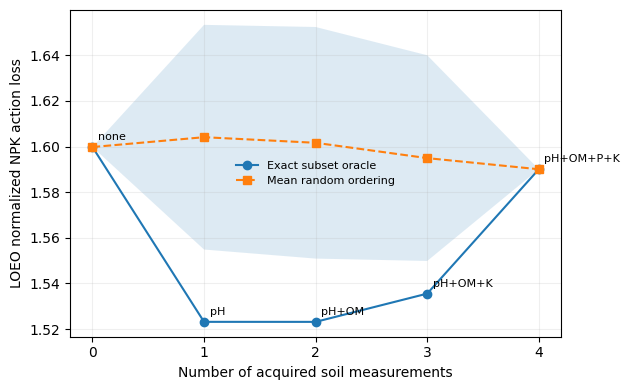

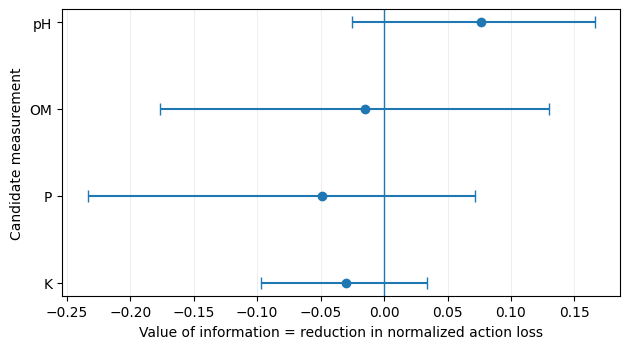

{
  "n_environments": 18,
  "ridge_alpha": 10.0,
  "baseline_loss": 1.5997873135441354,
  "ph_loss": 1.5231649525989268,
  "ph_improvement_pct": 4.789534227238057,
  "best_two_subset": "pH+OM",
  "best_two_loss": 1.5231533486717235,
  "full_loss": 1.5900503206379897,
  "full_vs_ph_degradation_pct": 4.391209758663272,
  "pH_voi": 0.07662236094520843,
  "pH_voi_ci95": [
    -0.02499900987729351,
    0.16591026788338364
  ],
  "greedy_exact_oracle_fraction": 0.3518376722817764,
  "greedy_mean_regret": 0.025013550344418004,
  "greedy_max_regret": 0.08526542887422606,
  "cost_budget_cases": 2612,
  "data_sha256": "4e63d390acfd6c1652118040e32e5b3e6f1a222c7664c0e948693c1fa23b6b39"
}
ALL CORE ASSERTIONS PASSED


In [7]:
# Figure 1
fig, ax = plt.subplots(figsize=(6.4,4.0))
ax.plot(oracle.k, oracle.loss_mean, marker="o", label="Exact subset oracle")
ax.plot(random_order.k, random_order.loss_mean, marker="s", linestyle="--", label="Mean random ordering")
ax.fill_between(random_order.k, random_order.loss_mean-random_order.loss_sd, random_order.loss_mean+random_order.loss_sd, alpha=.15)
for _, row in oracle.iterrows():
    ax.annotate(row.subset, (row.k,row.loss_mean), xytext=(4,5), textcoords="offset points", fontsize=8)
ax.set_xlabel("Number of acquired soil measurements"); ax.set_ylabel("LOEO normalized NPK action loss")
ax.set_xticks(range(5)); ax.legend(frameon=False, fontsize=8); ax.grid(alpha=.2)
fig.tight_layout(); fig.savefig(FIGURES/"figure1_frontier.png",dpi=300); fig.savefig(FIGURES/"figure1_frontier.pdf"); plt.show()

# Figure 2
v = voi.set_index("measurement").loc[["pH","OM","P","K"]].reset_index()
y = np.arange(len(v)); means=v.mean_voi.to_numpy(); low=means-v.ci_low.to_numpy(); high=v.ci_high.to_numpy()-means
fig, ax = plt.subplots(figsize=(6.4,3.6))
ax.errorbar(means,y,xerr=np.vstack([low,high]),fmt="o",capsize=4); ax.axvline(0,linewidth=1)
ax.set_yticks(y,v.measurement); ax.invert_yaxis(); ax.set_xlabel("Value of information = reduction in normalized action loss")
ax.set_ylabel("Candidate measurement"); ax.grid(axis="x",alpha=.2)
fig.tight_layout(); fig.savefig(FIGURES/"figure2_singleton_voi.png",dpi=300); fig.savefig(FIGURES/"figure2_singleton_voi.pdf"); plt.show()

ph_loss = loss_map["pH"]; full_loss=loss_map["pH+OM+P+K"]
pH_row = voi.loc[voi.measurement.eq("pH")].iloc[0]
PAPER_RESULTS = {
    "n_environments": len(df), "ridge_alpha": ALPHA,
    "baseline_loss": base_loss, "ph_loss": ph_loss,
    "ph_improvement_pct": 100*(base_loss-ph_loss)/base_loss,
    "best_two_subset": oracle.loc[oracle.k.eq(2),"subset"].iloc[0],
    "best_two_loss": oracle.loc[oracle.k.eq(2),"loss_mean"].iloc[0],
    "full_loss": full_loss,
    "full_vs_ph_degradation_pct": 100*(full_loss-ph_loss)/ph_loss,
    "pH_voi": pH_row.mean_voi,
    "pH_voi_ci95": [pH_row.ci_low,pH_row.ci_high],
    "greedy_exact_oracle_fraction": float((cost_results.regret<=1e-12).mean()),
    "greedy_mean_regret": float(cost_results.regret.mean()),
    "greedy_max_regret": float(cost_results.regret.max()),
    "cost_budget_cases": len(cost_results),
    "data_sha256": sha256,
}
with open(RESULTS/"paper_quantities.json","w") as f: json.dump(PAPER_RESULTS,f,indent=2)

# Scientific assertions used by the paper.
assert len(subset_results) == 16
assert oracle.loc[oracle.k.eq(1),"subset"].iloc[0] == "pH"
assert oracle.loc[oracle.k.eq(2),"subset"].iloc[0] == "pH+OM"
assert full_loss > ph_loss
assert len(cost_results) == 2612
assert pH_row.ci_low < 0 < pH_row.ci_high
print(json.dumps(PAPER_RESULTS, indent=2))
print("ALL CORE ASSERTIONS PASSED")